## UCS619 Quantum Computing: Lab Assignment-8
## Quantum Query Algorithms

Name: Smarth Kaushal | Roll No. 102497023 | Group: 3Q21 | Lab Instructor: Dr. Samya Muhuri

### Experiment 1: Phase Kickback

1. Explain the procedure for reverse CNOT using the concept of phase kickback. You can implement the reverse CNOT operation in Qiskit.

Circuit showing Phase Kickback (before final Hadamard):


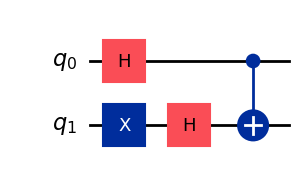

<IPython.core.display.Latex object>

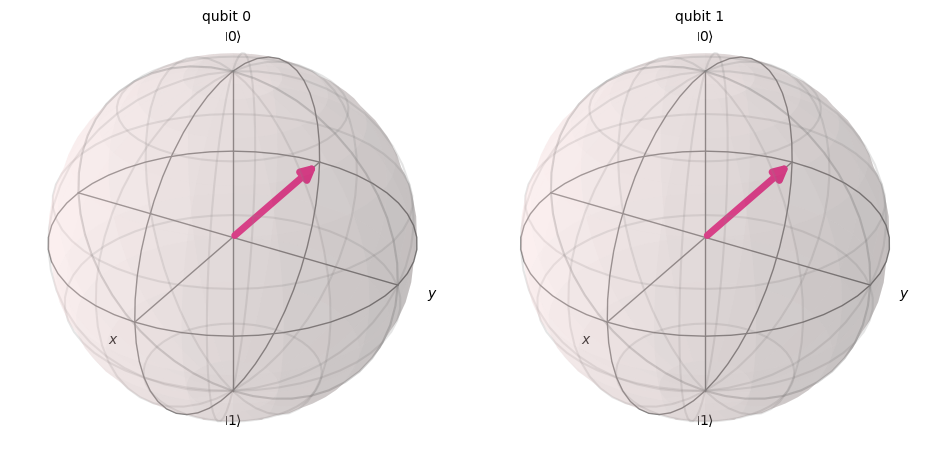

In [25]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_bloch_multivector

# 1. Create Circuit to show phase kickback
qc = QuantumCircuit(2)

qc.h(0) # Control in superposition
qc.x(1)
qc.h(1) # Target in |-> state

qc.cx(0, 1) 

# 2. Get Statevector
state = Statevector.from_instruction(qc)

# 3. Display Results
print("Circuit showing Phase Kickback (before final Hadamard):")
display(qc.draw('mpl'))
display(array_to_latex(state, prefix="\\text{Statevector } = "))
plot_bloch_multivector(state)


The control qubit is first put in superposition, and the target qubit is prepared in the |−⟩ state. When the CNOT gate is applied, the target does not flip but introduces a phase, which is transferred to the control qubit (phase kickback), i.e,

$$\boxed{|x\rangle |-\rangle \xrightarrow{\text{CNOT}} (-1)^x |x\rangle |-\rangle}$$

Applying Hadamard gates converts this phase into measurable output, effectively showing reverse CNOT behavior.

$$
\begin{aligned}
|0\rangle|1\rangle 
&\xrightarrow{H \otimes H} |+\rangle |-\rangle \\

&= \frac{1}{\sqrt{2}} \Big[ |0\rangle + |1\rangle \Big] \otimes |-\rangle \\

&= \frac{1}{\sqrt{2}} \Big[ |0\rangle |-\rangle + |1\rangle |-\rangle \Big] \\

&\quad \xrightarrow[\text{phase kickback}]{\text{CNOT}} \\


&= \frac{1}{\sqrt{2}} \Big[ |0\rangle |-\rangle - |1\rangle |-\rangle \Big] \\

&= \frac{|0\rangle - |1\rangle}{\sqrt{2}} \otimes |-\rangle \\

&= |-\rangle |-\rangle \xrightarrow{H \otimes H} |1\rangle |1\rangle
\end{aligned}
$$






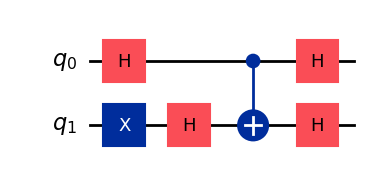

<IPython.core.display.Latex object>

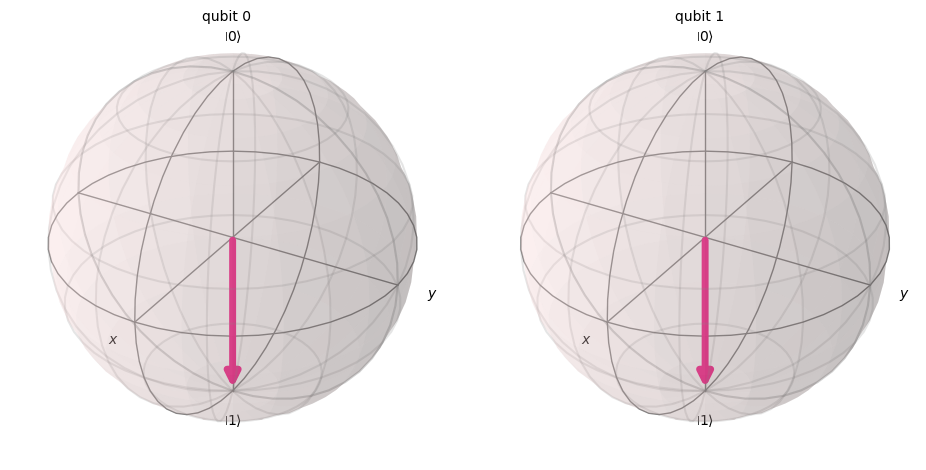

In [26]:
qc.h([0,1])

state = Statevector.from_instruction(qc)

display(qc.draw('mpl')) 
display(array_to_latex(state, prefix="\\text{Final State } |q_1 q_0\\rangle = "))
plot_bloch_multivector(state)

In [27]:
# Measurement verification
from qiskit_aer import AerSimulator

qc.measure_all()

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
print(result.get_counts())

{'11': 1024}


2. Implement the kickback process using the T gate.

Phase Kickback using T-gate:


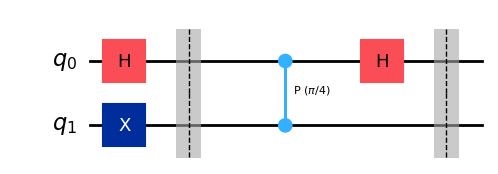

<IPython.core.display.Latex object>

{'10': 857, '11': 167}


In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_bloch_multivector
from qiskit_aer import AerSimulator
import numpy as np

# Create circuit
qc = QuantumCircuit(2)

qc.h(0) # control in superposition
qc.x(1) # target in |1>
qc.barrier()

# Controlled-T using kickback trick
# qc.cx(0,1)
# qc.t(1)
# qc.cx(0,1)
qc.cp(np.pi/4, 0, 1)
qc.h(0)
qc.barrier()

# Get statevector
state = Statevector.from_instruction(qc)

# Display
print("Phase Kickback using T-gate:")
display(qc.draw('mpl'))
display(array_to_latex(state, prefix="\\text{Statevector } = "))
plot_bloch_multivector(state)

qc.measure_all()

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
print(result.get_counts())

In this experiment, the T gate introduces a phase of $e^{i\pi/4}$ to the target qubit. Using controlled operations, this phase is transferred to the control qubit. The resulting statevector shows that the control qubit acquires the phase, demonstrating phase kickback using a general phase gate.

### Experiment 2: Deutsch Algorithm


CONSTANT_0


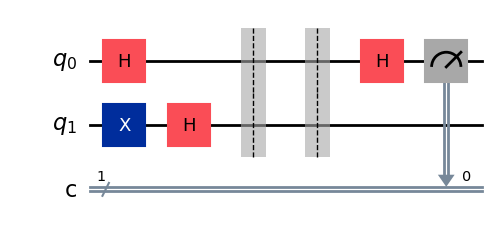

Counts: {'0': 1024}
Result: Constant

CONSTANT_1


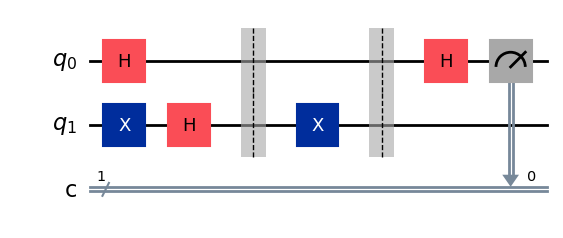

Counts: {'0': 1024}
Result: Constant

BALANCED_ID


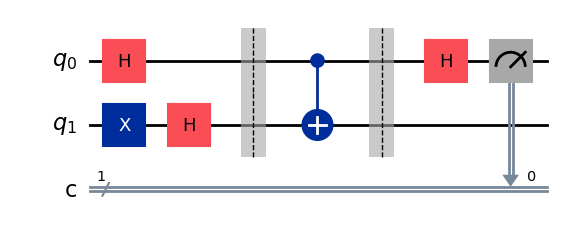

Counts: {'1': 1024}
Result: Balanced

BALANCED_NOT


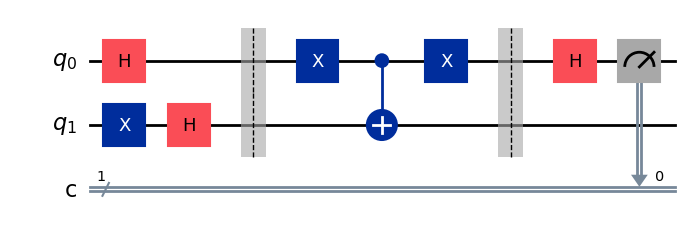

Counts: {'1': 1024}
Result: Balanced


In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def deutsch_circuit(oracle_type):
    qc = QuantumCircuit(2, 1)

    # Step 1: Initialization
    qc.x(1)            # |1>
    qc.h([0, 1])       # superposition
    qc.barrier()

    # Step 2: Phase Oracle
    if oracle_type == 'constant_0':
        pass
    elif oracle_type == 'constant_1':
        qc.x(1)
    elif oracle_type == 'balanced_id':
        qc.cx(0, 1)
    elif oracle_type == 'balanced_not':
        qc.x(0)
        qc.cx(0, 1)
        qc.x(0)

    qc.barrier()

    # Step 3: Interference
    qc.h(0)

    # Step 4: Measurement
    qc.measure(0, 0)

    return qc


# Simulator
sim = AerSimulator()

# Test all oracle types
oracles = ['constant_0', 'constant_1', 'balanced_id', 'balanced_not']
for oracle in oracles:
    qc = deutsch_circuit(oracle)

    print(f"\n{oracle.upper()}")
    display(qc.draw('mpl'))

    result = sim.run(qc, shots=1024).result()
    counts = result.get_counts()
    print("Counts:", counts)

    # Final decision
    measured = max(counts, key=counts.get) # Get the key with the highest count
    print("Result:", "Constant" if measured == '0' else "Balanced")

### Experiment 3: Deutsch-Jozsa Algorithm


CONSTANT_0


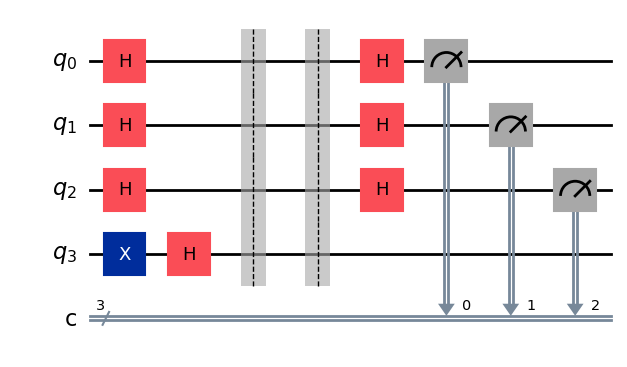

Counts: {'000': 1024}
Result: Constant

CONSTANT_1


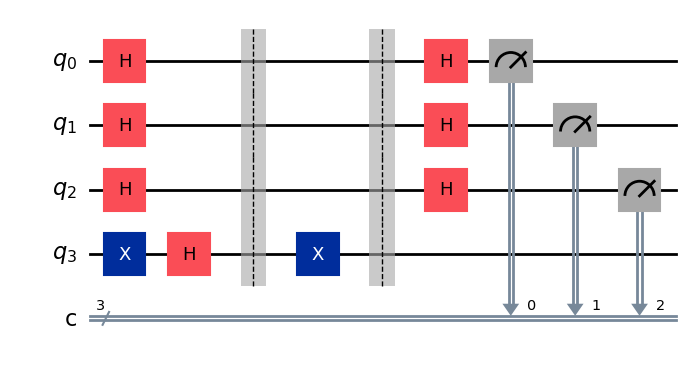

Counts: {'000': 1024}
Result: Constant

BALANCED


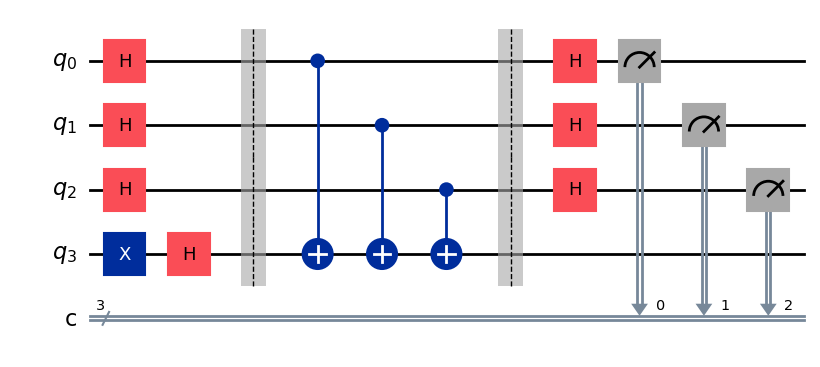

Counts: {'111': 1024}
Result: Balanced


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def dj_oracle(qc, oracle_type):
    if oracle_type == 'constant_0':
        pass
    elif oracle_type == 'constant_1':
        qc.x(n)
    elif oracle_type == 'balanced':
        for i in range(n):
            qc.cx(i, n)

n = 3
sim = AerSimulator()
for oracle_type in ['constant_0', 'constant_1', 'balanced']:
    qc = QuantumCircuit(n+1, n)

    # Step 1: Initialization
    qc.x(n)               # ancilla = |1>
    qc.h(range(n+1))      # superposition
    qc.barrier()

    # Step 2: Oracle
    oracle = dj_oracle(qc, oracle_type)
    qc.barrier()

    # Step 3: Interference
    qc.h(range(n))

    # Step 4: Measurement
    qc.measure(range(n), range(n))
    
    print(f"\n{oracle_type.upper()}")
    display(qc.draw('mpl'))
    result = sim.run(qc, shots=1024).result()
    counts = result.get_counts()
    print("Counts:", counts)

    # Decision logic
    all_zero = '0' * n
    if all_zero in counts and counts[all_zero] == 1024:
        print("Result: Constant")
    else:
        print("Result: Balanced")